In [1]:
# =========================================================
# SECTION 1: Import Basic Libraries
# =========================================================
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# =========================================================
# SECTION 2: Load Dataset
# =========================================================
df = pd.read_csv(r".\brain_tumor.csv")  # Load CSV file
df.head()  # Show first rows for inspection

,Unnamed: 0,X53416,M83670,X90908,M97496,X90908.1,U37019,R48602,T96548,X64559,...,H87456,R64130,H11125.1,U22055,L22524,M13699.1,X54489,T55008,M10065.2,y
0,0,70,-81,25,10,22,113,36,163,9,...,75,5,68,138,53,-4,123,2,19,tumor
1,1,108,-30,-7,60,0,24,8,113,-3,...,186,6,60,93,140,-3,271,-1,-51,tumor
2,2,75,-1,5,48,6,34,27,35,-1,...,186,225,94,62,39,-14,127,7,192,tumor
3,3,871,4,14,78,-6,85,65,227,19,...,77,6,78,30,87,-4,59,3,367,tumor
4,4,-92,-34,14,19,11,-6,27,-8,9,...,87,303,204,81,105,9,265,-2,126,tumor


In [3]:
# =========================================================
# SECTION 3: Basic Data Info
# =========================================================
df.info    # Overview of columns, non-null values, and types
df.isnull().sum()  # Count missing values per column
df.duplicated().sum()  # Count duplicated rows
df.shape  # Get dataset dimensions (rows, columns)
df["y"].unique()  # Check unique classes in target

array(['tumor', 'Normal'], dtype=object)

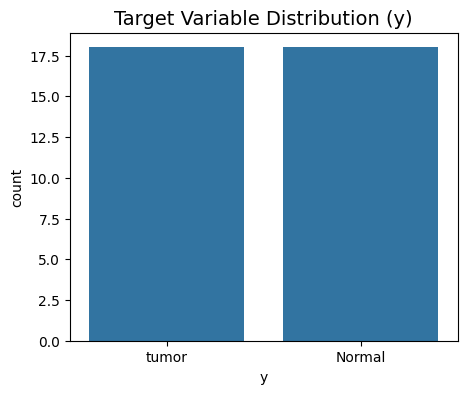

In [4]:
# =========================================================
# SECTION 4: Target Variable Visualization
# =========================================================
import seaborn as sns
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='y')
plt.title('Target Variable Distribution (y)', fontsize=14)
plt.show()


# Dataset is balanced enough → No SMOTE needed

In [5]:

# =========================================================
# SECTION 5: Feature / Target Separation
# =========================================================
X = df.drop(["Unnamed: 0", "y"], axis=1)  # Remove ID and target
y = df["y"]

# Label encode target: tumor → 1, normal → 0
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [6]:
# =========================================================
# SECTION 6: Import Sklearn & Imbalanced-Learn Tools
# =========================================================
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, make_scorer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn import set_config

In [7]:
# =========================================================
# SECTION 7: Create ML Pipeline for Logistic Regression
# =========================================================
pipeline = ImbPipeline([
    ('scaler', StandardScaler()),                  # Step 1: Scale features
    ('select', SelectKBest(score_func=f_classif, k=15)),  # Step 2: Select top 15 features
    ('pca', PCA(n_components=5)),                   # Step 3: Reduce dimensions to 5
    ('clf', LogisticRegression(max_iter=1000, C=0.01))  # Step 4: Logistic Regression
])

In [8]:
# =========================================================
# SECTION 8: Split Train/Test Data
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [9]:
# =========================================================
# SECTION 9: Fit Pipeline & Evaluate Logistic Regression
# =========================================================
pipeline.fit(X_train, y_train)
pipeline.score(X_test, y_test)  # Test accuracy

1.0

In [10]:
# =========================================================
# SECTION 10: Get Selected Feature Names
# =========================================================
selector = pipeline.named_steps['select']
selected_indices = selector.get_support(indices=True)
selected_gene_names = X.columns[selected_indices]  # Gene names after selection
selected_gene_names

# Create dataframe with selected features
df_selected = df[selected_gene_names]
df_selected

,M83670,M97496,T96548,H57136,J02854,U17077,X73502,H06524,T64297,M36634,X12496,M26697,X12466,R71676,M77836
0,-81,10,163,2,67,16,20,107,249,18,19,797,255,185,108
1,-30,60,113,-9,70,40,148,115,131,18,15,720,306,161,106
2,-1,48,35,-11,30,35,60,34,228,29,12,615,308,190,123
3,4,78,227,12,84,29,91,33,661,26,30,407,293,144,51
4,-34,19,-8,-6,22,47,137,19,125,17,10,557,287,96,122
5,-13,11,143,15,133,49,41,57,628,49,47,462,130,138,54
6,118,175,272,-2,116,41,63,60,139,24,10,617,235,151,67
7,-35,42,28,-9,67,13,15,78,128,16,13,720,263,112,67
8,31,105,11,-10,83,50,50,55,541,12,10,888,119,78,74
9,-79,41,225,-8,40,36,103,53,711,19,15,647,200,166,63


In [11]:
# =========================================================
# SECTION 11: Apply SMOTE to Balance Data
# =========================================================
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

       Feature  Importance
40      T76971    0.030000
7427    U17899    0.019222
35      J02854    0.015000
7382    H40095    0.015000
137   Z49269.1    0.015000
7298    M26697    0.014327
102     H06524    0.013756
7163  M36981.1    0.013704
53    L11708.1    0.013405
72    J03037.2    0.013089
7392    T86473    0.012987
77      Z50753    0.011296
67      U17077    0.010000
195     D11428    0.010000
7450    M77836    0.010000
7399  H30564.1    0.009457
7360    R71676    0.009333
6339    D14678    0.009333
316     T78104    0.009314
86      M12272    0.009314


C:\Users\p-fr\AppData\Local\Temp\ipykernel_3108\4073210829.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_importances[:20], x='Importance', y='Feature', palette='viridis')


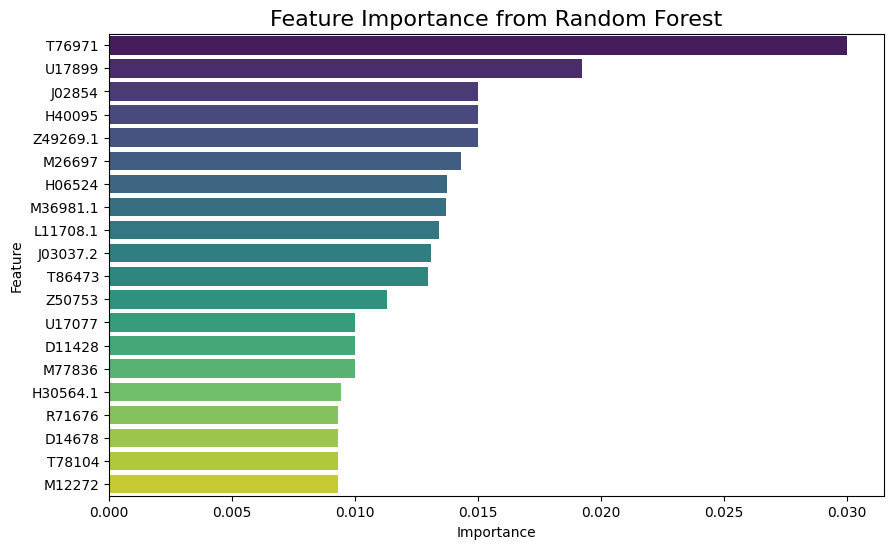

In [12]:
# =========================================================
# SECTION 12: Random Forest Feature Importance
# =========================================================
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_sm, y_train_sm)

# Feature importance extraction
importances = rf_model.feature_importances_
feat_importances = pd.DataFrame({
    'Feature': X_train_sm.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_importances[:20])

# Plot top 20 features from RF
plt.figure(figsize=(10,6))
sns.barplot(data=feat_importances[:20], x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance from Random Forest', fontsize=16)
plt.show()

In [13]:
# =========================================================
# SECTION 13: Build Custom Neural Network Function
# =========================================================
from sklearn.decomposition import PCA
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

def build_custom_nn(input_dim, layers_config, dropout_rate=0.5, activation='relu', output_units=1, output_activation='sigmoid'):
    """
    Build a neural network model with given configuration.

    Parameters:
        input_dim (int): Number of features
        layers_config (list): List of neurons per hidden layer
        dropout_rate (float): Dropout rate between layers
        activation (str): Hidden layer activation function
        output_units (int): Output neurons
        output_activation (str): Output activation (sigmoid for binary)
    """
    model = Sequential()

    # First layer with input dimension
    model.add(Dense(layers_config[0], activation=activation, input_dim=input_dim))
    model.add(Dropout(dropout_rate))

    # Additional hidden layers with dropout
    for units in layers_config[1:]:
        model.add(Dense(units, activation=activation))
        model.add(Dropout(dropout_rate))

    # Output layer
    model.add(Dense(output_units, activation=output_activation))

    # Compile model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    return model


c:\Users\p-fr\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.2632 - loss: 63.0903 - val_accuracy: 0.4444 - val_loss: 8.0017
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.5789 - loss: 81.9455 - val_accuracy: 0.6667 - val_loss: 7.8806
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.6842 - loss: 41.7991 - val_accuracy: 0.4444 - val_loss: 25.0234
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.6842 - loss: 43.7748 - val_accuracy: 0.4444 - val_loss: 35.2888
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.5789 - loss: 59.0835 - val_accuracy: 0.7778 - val_loss: 6.8982
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.6842 - loss: 24.7496 - val_accuracy: 0.7778 - val_loss: 4.2386
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.6316 - loss: 74.7780 - val_accuracy: 0.8889 - val_loss: 0.4071
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.7368 - loss: 23.3015 - val_accuracy: 1.0000 - va

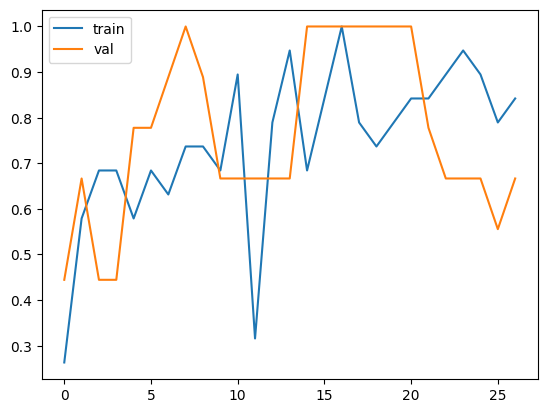

In [14]:
# =========================================================
# SECTION 14: Create & Train the Neural Network
# =========================================================
from tensorflow.keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Build model with specific layer sizes
model = build_custom_nn(input_dim=X_train_sm.shape[1], layers_config=[32,16,8], dropout_rate=0.2)

# Train model with validation split
history = model.fit(X_train_sm, y_train_sm, epochs=50, callbacks=[early_stop], verbose=1, validation_split=0.3)

# Plot training/validation accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()

In [15]:
# =========================================================
# SECTION 15: NN Model Evaluation
# =========================================================
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 1.0000 - loss: 1.2899e-09
Test Accuracy: 1.0000


# Handling Small Datasets 
In scenarios where the dataset size is limited, the risk of overfitting becomes one of the primary concerns in machine learning, especially when using complex models such as neural networks. To address this, we adopt a classic, self-correcting model alongside the neural network approach.

The classic model is chosen specifically because it tends to generalize well when data is scarce, making it less prone to memorizing noise in the dataset. We ensure that this classic model is trained in such a way that overfitting does not occur. Since it is inherently suitable for small datasets, it serves as a robust benchmark.

Next, we compare the accuracy of this classic model with that of the neural network. If both models achieve comparable accuracy, we can reasonably conclude that the neural network has not overfitted. This is because, under significant overfitting, a neural network would typically achieve a much higher accuracy on the training data than the benchmark model, but not necessarily on unseen data.

In our case, both models achieve high accuracy scores. This reinforces the conclusion that the neural network is performing well without overfitting and is effectively learning the underlying patterns in the data, even with the dataset being small.

The approach of pairing a classic model with a neural network in this way not only safeguards against overfitting but also provides a reference point for evaluating model performance on limited datasets.

In [17]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score


gb_model = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=100,
    random_state=42
)


gb_model.fit(X_train_sm, y_train_sm)


y_pred = gb_model.predict(X_test)


acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2%}")


Accuracy: 100.00%
